# **Probability - Coin Flips and Experiments**

In [2]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import seaborn as sns
sns.set(color_codes=True)
sns.set_style("white") 

In [3]:
np.random.uniform(low= 0.0, high=1.0)

0.10827207671054484

In [4]:
# generate a 'flip'
def flip(num = 1):
    flips = []
    
    for i in range(num):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append('H')                   # should be doing yeild here if you know 'generators'
        else:
            flips.append('T')
    return flips

In [5]:
flip()

['H']

In [6]:
flips = flip(10)
print(flips)

['T', 'H', 'T', 'T', 'H', 'H', 'H', 'T', 'T', 'T']


In [7]:
values, counts = np.unique(flips, return_counts=True)

In [9]:
values, counts

(array(['H', 'T'], dtype='<U1'), array([4, 6], dtype=int64))

# **Repdoduciable 'Randomness'**

 *there is only one way by which computer can produce randomness by taking noise from it surrrounding through sensors as a real number as we kknow that number is coming from the real world so it is completely random*

In [ ]:
# computers are 'deterministic'. You can not do 'random' in computers!

# So, you start with some 'seed' then do deterministic things
# this is called pseudo-randomness

# sometimes you want to suppress this!

np.random.seed(0)       # random numbers and seed

In [25]:
np.random.uniform(low=0.0, high=1.0)

0.896546595851063

In [34]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np

import seaborn as sns
sns.set(color_codes=True)
sns.set_style("white") 

# it will make code reproduce able
np.random.seed(1337)       # random numbers and seed

# generate a 'flip'
def flip(num = 1):
    flips = []
    
    for i in range(num):
        num = np.random.uniform(low=0.0, high=1.0)
        if num > 0.5:
            flips.append('H')                   # should be doing yeild here if you know 'generators'
        else:
            flips.append('T')
    return flips

# Flips
flips = flip(10)
values, counts = np.unique(flips, return_counts=True)

# print values/stats
# print(flip())
print(flips)
print(values, counts)

['T', 'T', 'T', 'T', 'T', 'H', 'T', 'H', 'H', 'T']
['H' 'T'] [3 7]


# **Probability of Flips**

In [41]:
from collections import Counter, defaultdict

def get_freqs(flips):
    keys = Counter(flips).keys()
    vals = Counter(flips).values()
    
    # print(keys)
    # print(vals)
    
    # return  dict(zip(keys, vals))         # bug: what if there are no 'H' or no 'T'
    
    return defaultdict(int, dict(zip(keys, vals)))

In [42]:
freqs = get_freqs(flips)
print(freqs)

defaultdict(<class 'int'>, {'T': 7, 'H': 3})


In [40]:
prob_h = freqs['H'] / len(flips)
print(prob_h)

0.3


# **Experiment: Prob calculated based on 1 flip upto N flips**

In [43]:
maximum_flips = 1000

probs = []
for num_flips in range(1, maximum_flips):
    flips = flip(num_flips)
    freqs = get_freqs(flips)
    prob_h = freqs['H'] / len(flips)
    
    probs.append(prob_h)
    
# print(probs)

In [44]:
print(freqs)

defaultdict(<class 'int'>, {'T': 505, 'H': 494})


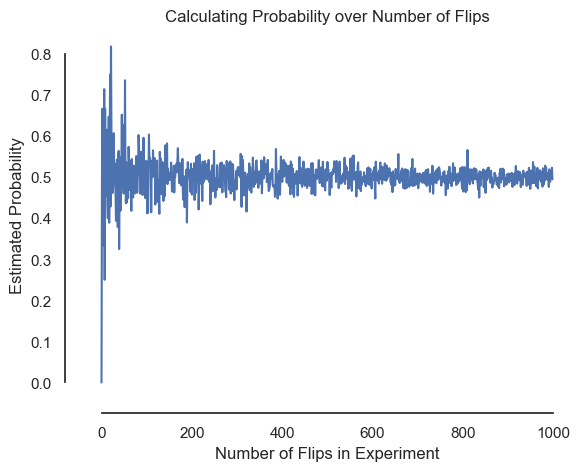

In [45]:
plt.plot(probs)
plt.ylabel('Estimated Probability')
plt.xlabel('Number of Flips in Experiment')
plt.title("Calculating Probability over Number of Flips")
sns.despine(offset=10, trim=True)       # move axes away
plt.show()

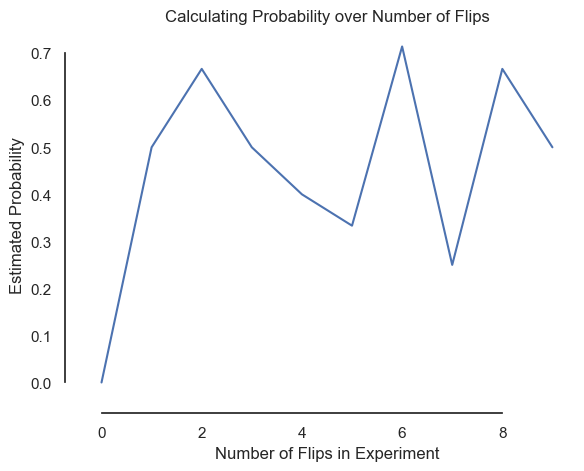

In [46]:
plt.plot(probs[:10])
plt.ylabel('Estimated Probability')
plt.xlabel('Number of Flips in Experiment')
plt.title("Calculating Probability over Number of Flips")
sns.despine(offset=10, trim=True)       # move axes away
plt.show()

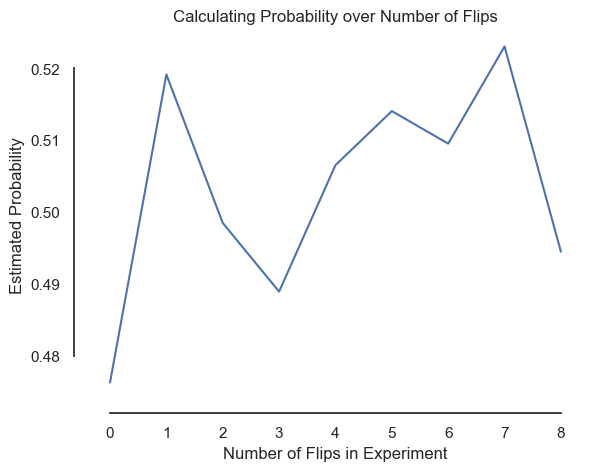

In [47]:
plt.plot(probs[maximum_flips-10:])
plt.ylabel('Estimated Probability')
plt.xlabel('Number of Flips in Experiment')
plt.title("Calculating Probability over Number of Flips")
sns.despine(offset=10, trim=True)       # move axes away
plt.show()

# **Bokeh For Interactive Plots**

In [ ]:
# !pip install bokeh

In [1]:
from bokeh.io import show, output_notebook
from bokeh.plotting import figure

output_notebook()

Loading BokehJS ...

In [2]:
p = figure(title= "Simple line Plot i Bokeh",
           x_axis_label = 'Number of Flips in Experiment',
           y_axis_label = 'Estimated Probability',
           width=580, height=380)

In [3]:
maximum_flips = 1000
# Add a line renderer with legend and line thinkness
r = list(range(1, maximum_flips))

probs = [1/x for x in r]

p.line(x=r, y = probs)

# Show the results
show(p)